# RGB Training v2 — R3D-18 with Gradual Unfreezing

## What is improved vs v1

- **Uniform random frame sampling** during training (not consecutive)
- **Gradual unfreezing** in 3 clear phases instead of freeze-all → unfreeze-all
- **Best checkpoint tracking** — saves best val accuracy model, not just latest
- **More augmentation** — ColorJitter and RandomGrayscale added
- **Easy resume** — any interruption can be recovered from the last saved checkpoint

## Training Strategy (3 phases)

| Phase | Epochs | Unfrozen layers | LR |
|-------|--------|-----------------|----|
| 1 | 1–5 | fc only | 1e-3 |
| 2 | 6–12 | layer4 + fc | 5e-4 |
| 3 | 13–20 | all layers | 1e-4 |

## Output
- Best checkpoint: `checkpoints/rgb_v2/best_model.pth`
- All epoch checkpoints: `checkpoints/rgb_v2/r3d_epoch_N.pth`
- Training history: `results/rgb_v2_history.json`

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!rsync -av "/content/drive/MyDrive/violence-detection/data/processed/rgb/rwf2000_clean/" /content/rwf2000_clean/

sending incremental file list
train/Fight/000008.avi
train/Fight/000009.avi
train/Fight/000010.avi
train/Fight/000011.avi
train/Fight/000012.avi
train/Fight/000013.avi
train/Fight/000014.avi
train/Fight/000015.avi
train/Fight/000016.avi
train/Fight/000017.avi
train/Fight/000018.avi
train/Fight/000019.avi
train/Fight/000020.avi
train/Fight/000021.avi
train/Fight/000022.avi
train/Fight/000023.avi
train/Fight/000024.avi
train/Fight/000025.avi
train/Fight/000026.avi
train/Fight/000027.avi
train/Fight/000028.avi
train/Fight/000029.avi
train/Fight/000030.avi
train/Fight/000031.avi
train/Fight/000032.avi
train/Fight/000033.avi
train/Fight/000034.avi
train/Fight/000035.avi
train/Fight/000036.avi
train/Fight/000037.avi
train/Fight/000038.avi
train/Fight/000039.avi
train/Fight/000040.avi
train/Fight/000041.avi
train/Fight/000042.avi
train/Fight/000043.avi
train/Fight/000044.avi
train/Fight/000045.avi
train/Fight/000046.avi
train/Fight/000047.avi
train/Fight/000048.avi
train/Fight/000049.avi
trai

In [3]:
import glob
print(len(glob.glob('/content/rwf2000_clean/train/Fight/*.avi')))      # should be ~800
print(len(glob.glob('/content/rwf2000_clean/train/NonFight/*.avi')))   # should be ~800
print(len(glob.glob('/content/rwf2000_clean/val/Fight/*.avi')))        # should be ~200
print(len(glob.glob('/content/rwf2000_clean/val/NonFight/*.avi')))     # should be ~200

800
800
200
200


In [4]:
import os

BASE         = '/content/drive/MyDrive/violence-detection'
DATA_ROOT = "/content/rwf2000_clean"          # RGB videos
SAVE_DIR     = f'{BASE}/checkpoints/rgb_v2'
RESULTS_DIR  = f'{BASE}/results'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Paths ready.')

Paths ready.


In [5]:
!pip install -q decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 111.1 MB/s eta 0:00:00


## Imports

In [6]:
import os
import json
import random
from glob import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import r3d_18
import torchvision.transforms as T
from decord import VideoReader, cpu
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Dataset

In [7]:
class RWF2000Dataset(Dataset):
    """
    Key fix vs v1:
    - Train: uniform RANDOM sampling across whole video (not consecutive window)
    - Val:   uniform LINSPACE sampling across whole video
    - More augmentation in train mode
    """
    def __init__(self, root, split, num_frames=16, size=224, mode='train'):
        self.num_frames = num_frames
        self.mode       = mode

        self.class_to_idx = {'NonFight': 0, 'Fight': 1}
        self.samples = []

        for cls, label in self.class_to_idx.items():
            folder = os.path.join(root, split, cls)
            vids   = sorted(glob(os.path.join(folder, '*.avi')))
            self.samples += [(v, label) for v in vids]

        if mode == 'train':
            self.tf = T.Compose([
                T.Resize((size, size)),
                T.RandomHorizontalFlip(0.5),
                T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
                T.RandomGrayscale(p=0.1),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
        else:
            self.tf = T.Compose([
                T.Resize((size, size)),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.samples)

    def _sample_indices(self, n):
        T_ = self.num_frames
        if n < T_:
            # video shorter than clip: repeat last frame
            return list(range(n)) + [n - 1] * (T_ - n)
        if self.mode == 'train':
            # FIX: uniform random sampling across the WHOLE video
            # previously: random consecutive window — missed most of the video
            return sorted(random.sample(range(n), T_))
        else:
            # val: evenly spaced across full video (deterministic)
            return torch.linspace(0, n - 1, T_).long().tolist()

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vr    = VideoReader(path, ctx=cpu(0))
        inds  = self._sample_indices(len(vr))

        frames = vr.get_batch(inds).asnumpy()          # (T, H, W, C)
        frames = torch.from_numpy(frames).float() / 255.0
        frames = frames.permute(0, 3, 1, 2)            # (T, C, H, W)

        frames = torch.stack([self.tf(frames[t]) for t in range(frames.shape[0])])
        clip   = frames.permute(1, 0, 2, 3)            # (C, T, H, W)
        return clip, torch.tensor(label)

In [8]:
train_ds = RWF2000Dataset(DATA_ROOT, split='train', num_frames=16, size=224, mode='train')
val_ds   = RWF2000Dataset(DATA_ROOT, split='val',   num_frames=16, size=224, mode='val')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} videos')
print(f'Val:   {len(val_ds)} videos')
x, y = next(iter(train_loader))
print(f'Batch shape: {x.shape}')  # should be (8, 3, 16, 224, 224)

Train: 1600 videos
Val:   400 videos
Batch shape: torch.Size([8, 3, 16, 224, 224])


## Model + Freezing Utilities

In [9]:
def build_model(device):
    model = r3d_18(weights='DEFAULT')
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)


def freeze_all(model):
    """Freeze every parameter."""
    for p in model.parameters():
        p.requires_grad = False


def unfreeze_layers(model, layer_names):
    """
    Unfreeze specific named children of the model.
    R3D-18 children: stem, layer1, layer2, layer3, layer4, avgpool, fc
    """
    for name, module in model.named_children():
        if name in layer_names:
            for p in module.parameters():
                p.requires_grad = True


def set_phase(model, phase):
    """
    Phase 1 (epochs 1-5):   train fc only
    Phase 2 (epochs 6-12):  train layer4 + fc
    Phase 3 (epochs 13-20): train everything
    """
    freeze_all(model)

    if phase == 1:
        unfreeze_layers(model, ['fc'])
        print('Phase 1: training fc only')

    elif phase == 2:
        unfreeze_layers(model, ['layer4', 'fc'])
        print('Phase 2: training layer4 + fc')

    elif phase == 3:
        for p in model.parameters():
            p.requires_grad = True
        print('Phase 3: training all layers')

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable params: {n_trainable:,}')


def get_phase(epoch):
    if epoch <= 5:   return 1
    elif epoch <= 12: return 2
    else:            return 3


def get_lr(phase):
    return {1: 1e-3, 2: 5e-4, 3: 1e-4}[phase]

## Checkpoint Utilities
Save and load everything needed to resume from any epoch.

In [10]:
def save_checkpoint(path, epoch, model, optimizer, scheduler, history, best_val_acc):
    torch.save({
        'epoch':          epoch,
        'model_state':    model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'history':        history,
        'best_val_acc':   best_val_acc,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    return ckpt['epoch'], ckpt['history'], ckpt['best_val_acc']


def find_latest_checkpoint(save_dir):
    """Returns path to the highest-epoch checkpoint, or None."""
    checkpoints = glob(os.path.join(save_dir, 'r3d_epoch_*.pth'))
    if not checkpoints:
        return None
    return max(checkpoints, key=lambda p: int(p.split('_epoch_')[1].replace('.pth', '')))

## Training Function

In [11]:
def run_one_epoch(model, loader, criterion, optimizer=None, device='cpu', train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Train' if train else 'Val', leave=False)

    for clips, labels in pbar:
        clips  = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            outputs = model(clips)
            loss    = criterion(outputs, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        pbar.set_postfix(loss=f'{loss.item():.4f}')
        total_loss += loss.item() * clips.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1

## Main Training Loop

**To resume after interruption:** just run this cell again — it will automatically find the latest checkpoint and continue from where it stopped.

In [12]:
TOTAL_EPOCHS = 20
criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Build model ──────────────────────────────────────────────────────────────
model = build_model(device)

# ── Check for existing checkpoint ────────────────────────────────────────────
latest_ckpt = find_latest_checkpoint(SAVE_DIR)

if latest_ckpt:
    print(f'Resuming from: {latest_ckpt}')

    # Reconstruct optimizer/scheduler for the phase of the saved epoch
    # (we need them before loading state dicts)
    saved_epoch = int(latest_ckpt.split('_epoch_')[1].replace('.pth', ''))
    phase       = get_phase(saved_epoch + 1)  # phase for NEXT epoch
    set_phase(model, phase)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=get_lr(phase), weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6
    )

    start_epoch, history, best_val_acc = load_checkpoint(
        latest_ckpt, model, optimizer, scheduler, device
    )
    start_epoch += 1
    print(f'Resuming from epoch {start_epoch}, best val acc so far: {best_val_acc:.4f}')

else:
    print('No checkpoint found — starting from scratch.')
    start_epoch  = 1
    best_val_acc = 0.0
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
    }
    # Start in phase 1
    set_phase(model, 1)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=get_lr(1), weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6
    )

# ── Training loop ────────────────────────────────────────────────────────────
current_phase = get_phase(start_epoch)

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):

    # ── Phase transition check ────────────────────────────────────────────────
    new_phase = get_phase(epoch)
    if new_phase != current_phase:
        current_phase = new_phase
        print(f'\n── Phase transition at epoch {epoch} ──')
        set_phase(model, current_phase)
        # Rebuild optimizer for newly unfrozen parameters
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=get_lr(current_phase), weight_decay=1e-4
        )
        # Reset scheduler for remaining epochs
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=TOTAL_EPOCHS - epoch + 1, eta_min=1e-6
        )

    # ── Train + val ───────────────────────────────────────────────────────────
    train_loss, train_acc, train_f1 = run_one_epoch(
        model, train_loader, criterion, optimizer, device, train=True
    )
    val_loss, val_acc, val_f1 = run_one_epoch(
        model, val_loader, criterion, device=device, train=False
    )

    scheduler.step()

    # ── Record history ────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d} [Phase {current_phase}] lr={lr_now:.2e}')
    print(f'  Train: loss={train_loss:.4f}  acc={train_acc:.3f}  f1={train_f1:.3f}')
    print(f'  Val:   loss={val_loss:.4f}  acc={val_acc:.3f}  f1={val_f1:.3f}')

    # ── Save best model separately ────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(SAVE_DIR, 'best_model.pth')
        torch.save(model.state_dict(), best_path)
        print(f'  ★ New best val acc: {best_val_acc:.4f} — saved to best_model.pth')

    # ── Save epoch checkpoint (for resuming) ──────────────────────────────────
    ckpt_path = os.path.join(SAVE_DIR, f'r3d_epoch_{epoch}.pth')
    save_checkpoint(ckpt_path, epoch, model, optimizer, scheduler, history, best_val_acc)
    print(f'  Checkpoint saved: r3d_epoch_{epoch}.pth')
    print('-' * 50)

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:02<00:00, 59.3MB/s]


Resuming from: /content/drive/MyDrive/violence-detection/checkpoints/rgb_v2/r3d_epoch_17.pth
Phase 3: training all layers
  Trainable params: 33,167,298
Resuming from epoch 18, best val acc so far: 0.8800


Train:   0%|          | 0/200 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

...

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 19 [Phase 3] lr=4.77e-06
  Train: loss=0.2365  acc=0.991  f1=0.991
  Val:   loss=0.4283  acc=0.873  f1=0.869
  Checkpoint saved: r3d_epoch_19.pth
--------------------------------------------------


Train:   0%|          | 0/200 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 20 [Phase 3] lr=1.00e-06
  Train: loss=0.2292  acc=0.993  f1=0.993
  Val:   loss=0.4265  acc=0.865  f1=0.859
  Checkpoint saved: r3d_epoch_20.pth
--------------------------------------------------

Training complete. Best val accuracy: 0.8800


## Save Training History

In [13]:
history_path = os.path.join(RESULTS_DIR, 'rgb_v2_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f)
print('History saved to:', history_path)

History saved to: /content/drive/MyDrive/violence-detection/results/rgb_v2_history.json


## Plot Training Curves

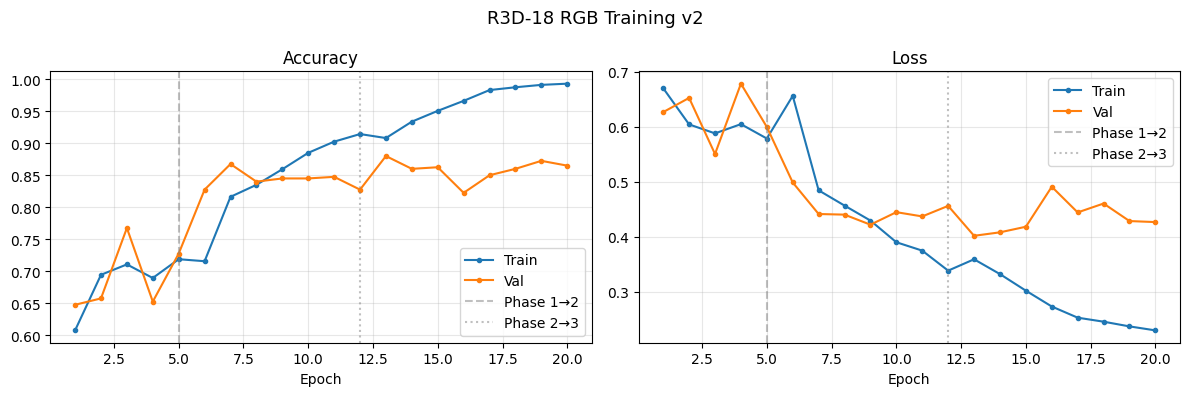

Plot saved to: /content/drive/MyDrive/violence-detection/results/rgb_v2_training_curves.png


In [14]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(epochs, history['train_acc'], label='Train', marker='o', markersize=3)
axes[0].plot(epochs, history['val_acc'],   label='Val',   marker='o', markersize=3)
axes[0].axvline(x=5,  color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[0].axvline(x=12, color='gray', linestyle=':',  alpha=0.5, label='Phase 2→3')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
axes[1].plot(epochs, history['val_loss'],   label='Val',   marker='o', markersize=3)
axes[1].axvline(x=5,  color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[1].axvline(x=12, color='gray', linestyle=':',  alpha=0.5, label='Phase 2→3')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('R3D-18 RGB Training v2', fontsize=13)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'rgb_v2_training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to:', plot_path)

## Run RGB Inference for Fusion

Run this after training to generate `rgb_val_probs.npy` for the fusion notebook.
Uses the **best_model.pth** checkpoint, not the last epoch.

In [15]:
import numpy as np
import pickle

# Load best model
best_model = build_model(device)
best_model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, 'best_model.pth'), map_location=device, weights_only=False)
)
best_model.eval()
print('Best model loaded.')

# Load val order from pose pkl to ensure alignment with GCN predictions
PKL_PATH = f'{BASE}/data/processed/pose/pkl/rwf_pose.pkl'
with open(PKL_PATH, 'rb') as f:
    pose_data = pickle.load(f)
val_order = pose_data['split']['val']
print(f'Val order loaded: {len(val_order)} videos')

# Dataset ordered exactly as GCN val set
class OrderedValDataset(Dataset):
    def __init__(self, val_order, rgb_root, num_frames=16, size=224):
        self.samples = []
        for frame_dir in val_order:
            split, cls, name = frame_dir.split('/')
            path  = os.path.join(rgb_root, split, cls, f'{name}.avi')
            label = 1 if cls == 'Fight' else 0
            self.samples.append((path, label))
        self.num_frames = num_frames
        self.tf = T.Compose([
            T.Resize((size, size)),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vr   = VideoReader(path, ctx=cpu(0))
        inds = torch.linspace(0, len(vr) - 1, self.num_frames).long().tolist()
        frames = vr.get_batch(inds).asnumpy()
        frames = torch.from_numpy(frames).float() / 255.0
        frames = frames.permute(0, 3, 1, 2)
        frames = torch.stack([self.tf(frames[t]) for t in range(frames.shape[0])])
        return frames.permute(1, 0, 2, 3), torch.tensor(label)

ordered_ds     = OrderedValDataset(val_order, DATA_ROOT)
ordered_loader = DataLoader(ordered_ds, batch_size=8, shuffle=False, num_workers=2)

rgb_probs_list, rgb_labels_list = [], []
with torch.no_grad():
    for clips, labels in tqdm(ordered_loader, desc='RGB inference'):
        clips = clips.to(device)
        probs = torch.softmax(best_model(clips), dim=1).cpu().numpy()
        rgb_probs_list.extend(probs)
        rgb_labels_list.extend(labels.numpy())

rgb_probs_arr  = np.array(rgb_probs_list)
rgb_labels_arr = np.array(rgb_labels_list)

from sklearn.metrics import accuracy_score
print(f'RGB v2 val accuracy: {accuracy_score(rgb_labels_arr, np.argmax(rgb_probs_arr, axis=1)):.4f}')

np.save(os.path.join(SAVE_DIR, 'rgb_v2_val_probs.npy'),  rgb_probs_arr)
np.save(os.path.join(SAVE_DIR, 'rgb_v2_val_labels.npy'), rgb_labels_arr)
print('Probs saved — ready for fusion notebook.')

Best model loaded.
Val order loaded: 400 videos


RGB inference:   0%|          | 0/50 [00:00<?, ?it/s]

RGB v2 val accuracy: 0.8800
Probs saved — ready for fusion notebook.
